# Simulation validation: drains

The goal of this notebook is to validate our simulator. We are searching to reproduce the results from Monatgne, Ginès, Fujii and Rondelez in the paper Boosting functionality of synthetic DNA circuits
with tailored deactivation"

In [3]:
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import numpy as np
import argparse
import os
from typing import NamedTuple


from strands import Signal, Drain, Template
from PEN_simulation import System

In [4]:
def create_system(drain_concentration, temperature=37):
    """Create a system with a signal and a drain"""
    # Create a signal
    alpha = Signal(name="alpha", sequence="CATTCTGACGAG", concentration=0.00000001, protected=False, IsDrained=True)
    
    # Create a drain
    drain = Drain(name="drain", input=alpha, concentration=drain_concentration, sequence="AAAACTCGTCAGAATG", protected=True)
    
    # Create a template
    template = Template(name="aT_alpha", sequence='CTCGTCAGAATGCTCGTCAGAAT', input=alpha, output=alpha, concentration=10, nick="bsmI", protected=True, loading=False)
    
    # Create a system
    system = System(temperature=temperature)
    system.add_signal(alpha)
    system.add_drain(drain)
    system.add_template(template)
    
    return system

def compute_Ct(syst,y,t):
    """ Compute the time at which the concentration of the signal is 20% of its maximal value"""
    conc=y[:,syst.find_index('alpha',"alone")]
    conc_20 = 0.2 * conc[-1]
    if conc_20 < 1e-10:
        return 0
    b=len(conc)-1
    a=1
    # Binary search for c such that conc[c] = conc_20
    # This is the first index where conc[c] > conc_20

    while a<b :
        c=(a+b)//2
        if conc[c]<conc_20:
            a=c+1
        else:
            b=c
    return t[a]

In [5]:
alpha_to_alpha1='CTCGTCAGAATGCTCGTCAGAATG'
alpha_to_alpha2='CTCGTCAGAATGCTCGTCAGAAT'
alpha_to_alpha3='CTCGTCAGAATGCTCGTCAGAA'
alpha_to_alpha4='CTCGTCAGAATGCTCGTCAGA'

drain1='AAAACTCGTCAGAATG'
drain2='TCTCGTCAGAATG'
drain3='TTCTCGTCAGAATG'
drain4='TTTCTCGTCAGAATG'
drain5='TTTTCTCGTCAGAATG'
drain6='TTTTTCTCGTCAGAATG'
seqs_drain=[drain2, drain3,drain4, drain5, drain6]
seqs_temp=[alpha_to_alpha1, alpha_to_alpha2, alpha_to_alpha3, alpha_to_alpha4]

## Plot of Fig 3a1

We plot here the results of the figure 3a1: the oncentration of alpha vs time for different drain concentrations, at 45°C.

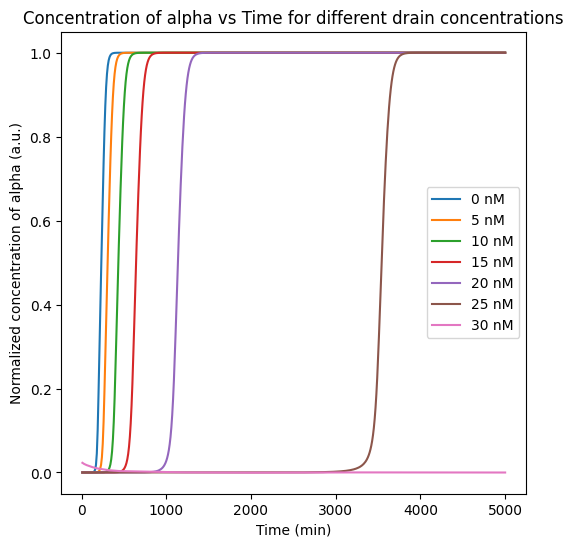

In [4]:
syst = create_system(drain_concentration=0, temperature=45)
syst.drains[0].sequence=drain1
syst.templates[0].sequence=alpha_to_alpha2
syst.templates[0].concentration=50
syst.temperature=45
t = np.linspace(0, 5000*60, 501)

syst.drains[0].concentration=0
y0 = syst.solve_system(t)
syst.drains[0].concentration=5
y1=syst.solve_system(t)
syst.drains[0].concentration=10
y2=syst.solve_system(t)
syst.drains[0].concentration=15
y3=syst.solve_system(t)
syst.drains[0].concentration=20
y4=syst.solve_system(t)
syst.drains[0].concentration=25
y5=syst.solve_system(t)
syst.drains[0].concentration=30
y6=syst.solve_system(t)
plt.figure(figsize=(6, 6))
plt.plot(t[1:]/60, y0[1:, syst.find_index('alpha','alone')]/max(y0[:, syst.find_index('alpha','alone')]), label='0 nM')
plt.plot(t[1:]/60, y1[1:, syst.find_index('alpha','alone')]/max(y1[:, syst.find_index('alpha','alone')]), label='5 nM')
plt.plot(t[1:]/60, y2[1:, syst.find_index('alpha','alone')]/max(y2[:, syst.find_index('alpha','alone')]), label='10 nM')
plt.plot(t[1:]/60, y3[1:, syst.find_index('alpha','alone')]/max(y3[:, syst.find_index('alpha','alone')]), label='15 nM')
plt.plot(t[1:]/60, y4[1:, syst.find_index('alpha','alone')]/max(y4[:, syst.find_index('alpha','alone')]), label='20 nM')
plt.plot(t[1:]/60, y5[1:, syst.find_index('alpha','alone')]/max(y5[:, syst.find_index('alpha','alone')]), label='25 nM')
plt.plot(t[1:]/60, y6[1:, syst.find_index('alpha','alone')]/max(y6[:, syst.find_index('alpha','alone')]), label='30 nM')

plt.xlabel('Time (min)')
plt.ylabel('Normalized concentration of alpha (a.u.)')
plt.legend()
plt.title('Concentration of alpha vs Time for different drain concentrations')
plt.savefig('Sim_fig3a1.png')
plt.show()
syst.unmalloc()

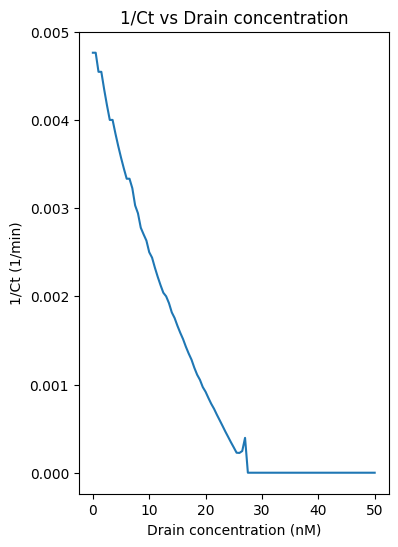

In [5]:
# Plot of fig 3a2
syst = create_system(drain_concentration=0, temperature=45)
syst.drains[0].sequence=drain1
syst.templates[0].sequence=alpha_to_alpha2
syst.templates[0].concentration=50
syst.temperature=45
t = np.linspace(0, 5000*60, 501)
Ct=[]
drain_concs=np.linspace(0, 50, 101)

for drain_concentration in drain_concs:
    syst.drains[0].concentration=drain_concentration
    y=syst.solve_system(t)
    bla = compute_Ct(syst,y,t)
    if bla ==0:
        Ct.append(0)
    else:
        Ct.append(60/bla)
plt.figure(figsize=(4, 6))
plt.plot(drain_concs, Ct, label='Ct')
 
plt.xlabel('Drain concentration (nM)')
plt.ylabel('1/Ct (1/min)')
plt.title('1/Ct vs Drain concentration')
plt.savefig('Sim_fig3a2.png')
plt.show()
syst.unmalloc()

We obtain the same behaviour as in the article : 0 is an unstable equilibrium point until the drain reaches a certain concentration.
The critical drain concentration is here of 28 nM.

## Check: Plot of the stable equilibrium points

To be sure that we achieve a bistable state, we will plot the evolution of the equilibrium state depending on the drain concentration.

Concentration of alpha at t=-1: 0.983402763436702


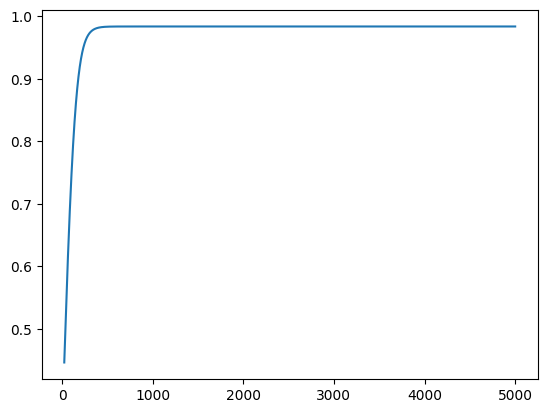

In [6]:
 # Test : If the signal is has a strong enough concentration, the drain should not be able to cut it entirely, even though [dT] is bigger than its critical value
syst = create_system(drain_concentration=0, temperature=45)
syst.drains[0].sequence=drain1
syst.drains[0].concentration=40
syst.templates[0].sequence=alpha_to_alpha2
syst.templates[0].concentration=50
syst.signals[0].concentration=25
syst.temperature=45
t = np.linspace(0, 5000*60, 10001)
y=syst.solve_system(t)
print("Concentration of alpha at t=-1:", y[-1, syst.find_index('alpha','alone')])
plt.plot(t[50:]/60, y[50:, syst.find_index('alpha','alone')], label='0 nM')
plt.show()
syst.unmalloc()

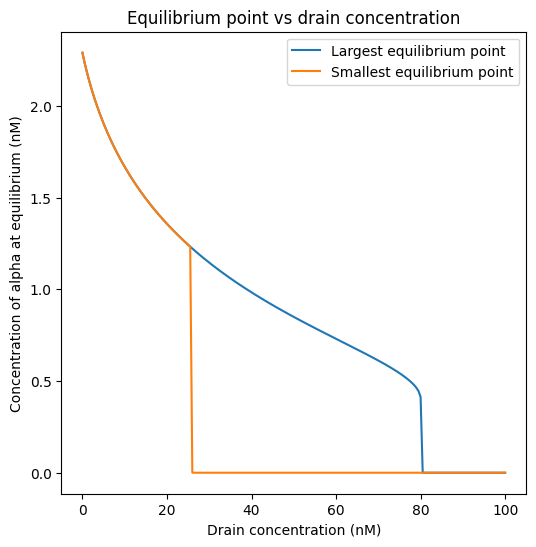

In [16]:
## Plot of the equilibrium point evolution.

t = np.linspace(0, 5000*60, 10001)
final_conc_from_much = []
final_conc_from_0 = []
drain_concs = np.linspace(0, 100, 201)

# syst.drains[0].concentration=0
# y = syst.solve_system(t)
# plt.plot(t[1:]/60, y[1:, syst.find_index('alpha','alone')], label='0 nM')
# plt.show()

for drain_concentration in drain_concs:
    syst = create_system(drain_concentration=0, temperature=45)
    syst.drains[0].sequence=drain1
    syst.templates[0].sequence=alpha_to_alpha2
    syst.templates[0].concentration=50
    syst.signals[0].concentration=100
    syst.drains[0].concentration = drain_concentration
    y = syst.solve_system(t)
    # print("Concentration of alpha at t=-1:", y[-1, syst.find_index('alpha', 'alone')], "for drain concentration", drain_concentration)
    final_conc_from_much.append(y[-1, syst.find_index('alpha', 'alone')])
    syst.unmalloc()


for drain_concentration in drain_concs:
    syst = create_system(drain_concentration=0, temperature=45)
    syst.drains[0].sequence=drain1
    syst.templates[0].sequence=alpha_to_alpha2
    syst.templates[0].concentration=50
    syst.signals[0].concentration=0.00000001
    syst.drains[0].concentration = drain_concentration
    y = syst.solve_system(t)
    final_conc_from_0.append(y[-1, syst.find_index('alpha', 'alone')])
    syst.unmalloc()

plt.figure(figsize=(6, 6))
plt.plot(drain_concs, final_conc_from_much, label='Largest equilibrium point')
plt.plot(drain_concs, final_conc_from_0, label='Smallest equilibrium point')
plt.xlabel('Drain concentration (nM)')
plt.ylabel('Concentration of alpha at equilibrium (nM)')
plt.title('Equilibrium point vs drain concentration')
plt.legend()
plt.savefig('Equilibriums.pdf')
plt.show()


## Plot of Fig 3b

We now to plot figure 3b: the evolution of 1/Ct for differrent drain sequences. The goal is to analyze the impact of the drain length.

We first plot the evolution of alpha vs time before plotiing 1/Ct vs drain concentration for for different drain sequences.

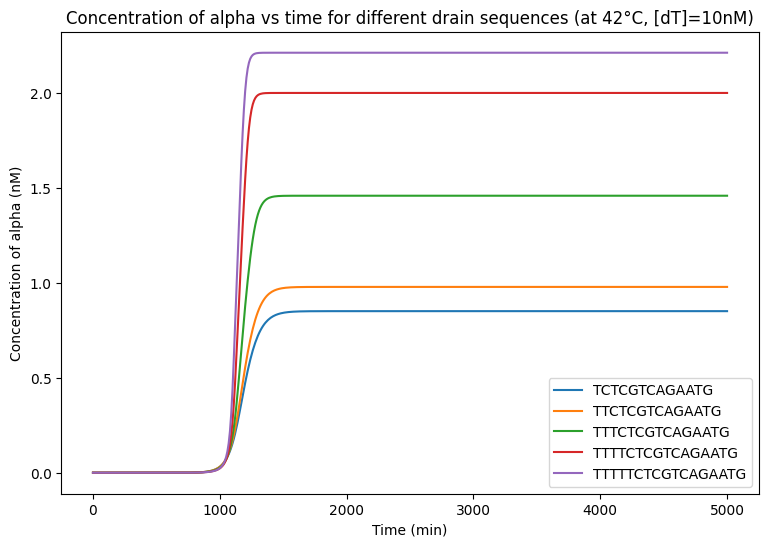

In [19]:
# Plot of Fig 3b_bonus: Concentration of alpha vs Time for different drain sequences (at 42°C, [dT]=10nM)
syst = create_system(drain_concentration=0, temperature=45)
syst.templates[0].sequence=alpha_to_alpha3
syst.templates[0].concentration=50
syst.drains[0].concentration=10
syst.temperature=42
t = np.linspace(0, 5000*60, 501)
plt.figure(figsize=(9,6))
for seq in seqs_drain:
    Ct=[]
    syst.drains[0].sequence=seq
    y=syst.solve_system(t)
    bla =compute_Ct(syst,y,t)
    plt.plot(t[:]/60, y[:, syst.find_index('alpha','alone')], label=seq)
    # plt.axvline(x=bla / 60, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Time (min)')
plt.ylabel('Concentration of alpha (nM)')
plt.title('Concentration of alpha vs time for different drain sequences (at 42°C, [dT]=10nM)')
plt.legend()
plt.savefig('Sim_fig3b_bonus.pdf')
plt.show()
syst.unmalloc()

As reported in the article, short drains penalize the amplification rates.

The critical concentration of drain template doesn't depend on Delta_ext. All drain sequences lead to an amplification at the same time... 

This simulation  is inconsistent with The article Boosting functionnality, however there is a mistake in this article about the computation of binding rates (we should have K_2 = exp ((-DrG2 - Delta_ext)/RT),  K_1i = exp ((-DrG2 + Delta_bind)/RT) and  K_1o = exp (-DrG2)/RT).

A simple maths analysis shows that there is no appearant reson for the critical drain concenttration to be dependant on Delta_ext.

However, experimentally, this dependance can maybe come from polymerase leak if the tail of the extended trigger is not long enough.

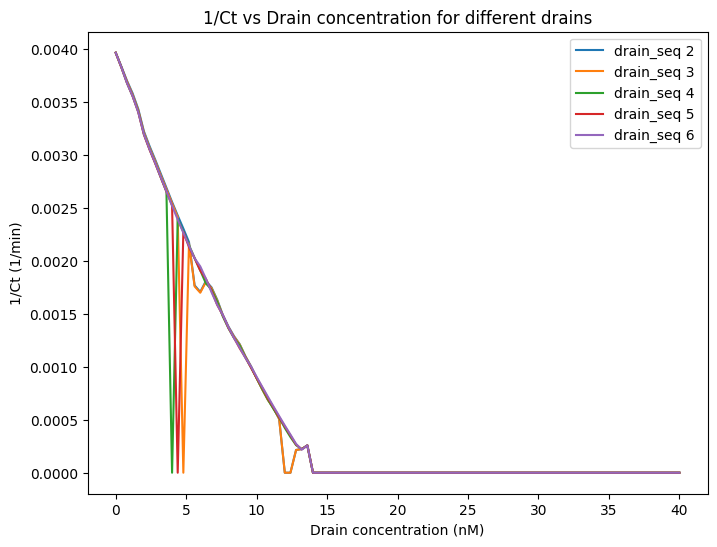

In [11]:
# Plot of fig 3b: 1/Ct vs Drain concentration for different drains

syst = create_system(drain_concentration=0, temperature=42)
syst.templates[0].sequence = alpha_to_alpha3
syst.templates[0].concentration=50

syst.temperature = 42

t = np.linspace(0, 5000 * 60, 10001)  # time in seconds
drain_concs = np.linspace(0, 40, 101)  # drain concentrations

res = []

for seq in seqs_drain:
    Ct_values = []
    syst.drains[0].sequence = seq
    for drain_concentration in drain_concs:
        syst.drains[0].concentration = drain_concentration
        y = syst.solve_system(t)
        Ct_val = compute_Ct(syst, y, t)  # Ct in seconds

        # Handle edge cases where Ct is 0 or None
        if Ct_val in [0, None]:
            Ct_values.append(0)
        else:
            Ct_values.append(60 / Ct_val)  # 1/Ct in 1/min

    res.append(Ct_values)

# Plotting
plt.figure(figsize=(8, 6))
for i, Ct in enumerate(res):
    plt.plot(drain_concs, Ct, label=f'drain_seq {i + 2}')

plt.xlabel('Drain concentration (nM)')
plt.ylabel('1/Ct (1/min)')
plt.title('1/Ct vs Drain concentration for different drains')
plt.legend()
plt.savefig('Sim_fig3b.png')
plt.show()

syst.unmalloc()


Up to simulation errors, we find the same critical concentration for all drain sequences.

## Plot of fig 3c

We plot the same than Fig 3c: the concentration of alpha vs time for different drain concentrations and different template sequences. The goal is to analyze the dependence on the template sequence.

We change again the temperature, otherwise, we don't have any signal for template 3 and 4 (alpha unbinds faster than the action of the polymerase).

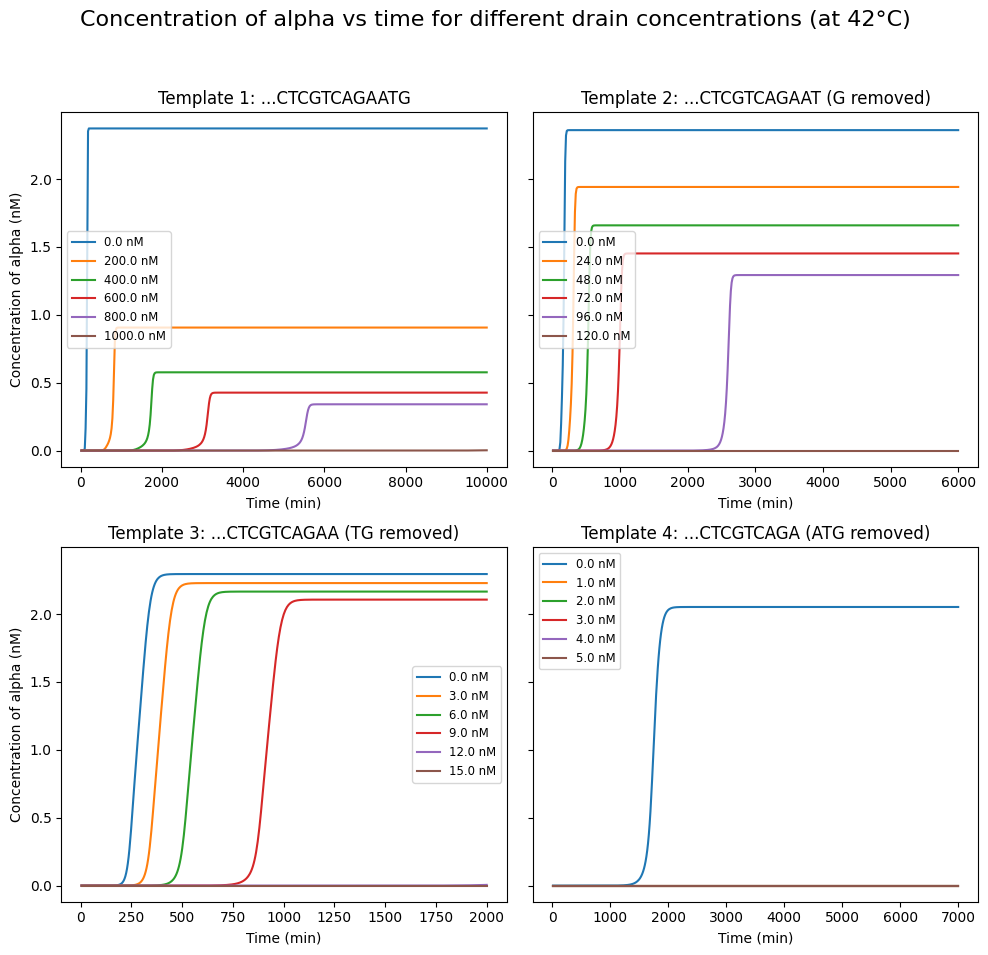

In [12]:
def strikethrough(text):
    return ''.join(c + '\u0336' for c in text)

# Set up system
syst = create_system(drain_concentration=0, temperature=42)
syst.drains[0].sequence = drain1
syst.templates[0].concentration = 50

# Parameters
drain_concentrations_list = [
    np.linspace(0, 1000, 6),
    np.linspace(0, 120, 6),
    np.linspace(0, 15, 6),
    np.linspace(0, 5, 6)
]
times = [
    np.linspace(0, 10000*60, 501),
    np.linspace(0, 6000*60, 501),
    np.linspace(0, 2000*60, 501),
    np.linspace(0, 7000*60, 501)
]

# Create a 2x2 subplot
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), sharey=True)
axes = axes.flatten()  # Flatten for easier iteration

# Loop over templates and axes
for ax, seq, conc_list, t, i in zip(axes, seqs_temp, drain_concentrations_list, times, range(1, 5)):
    syst.templates[0].sequence = seq
    for conc in conc_list:
        syst.drains[0].concentration = conc
        y = syst.solve_system(t)
        ax.plot(t[1:]/60, y[1:, syst.find_index('alpha', 'alone')], label=f'{conc} nM')
    
    
    
    ax.set_xlabel('Time (min)')
    if i>1:
        suffix = seqs_temp[0][-i+1:]
        ax.set_title(f'Template {i}: ...{seq[12:]} ({(suffix)} removed)')
    else:
        ax.set_title(f'Template {i}: ...{seq[12:]}')
    if i in [1, 3]:  # First column
        ax.set_ylabel('Concentration of alpha (nM)')
    ax.legend(fontsize='small')

fig.suptitle('Concentration of alpha vs time for different drain concentrations (at 42°C)', fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('Sim_fig3c.pdf')
plt.show()
syst.unmalloc()



We obtain the same behaviour as in the article (up to time and concentrations values). The best template sequence seems to be the one with two removed bases on the 3' end (template 3). 